##### **<font color='purple'>Encryption Theory Assignment: Using Block-Based Distribution Technique in Least Significant Bit (LSB) steganography</font>**
##### **<font color='purple'>Students' Names: Lina Abureesh, Bailasan Qa'dan</font>**
##### **<font color='purple'>University IDs: 1211985, 1220687</font>**

#### Import Libraries

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import copy

#### Determine block size

In [2]:
block_size = 4

#### load the cover image

In [3]:
img = cv.imread("huffman.png")

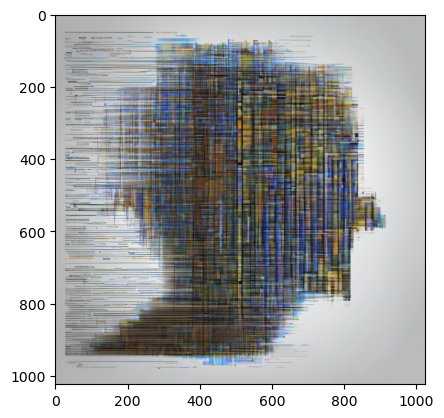

In [4]:
# show the image
plt.imshow(img)

#### Implement a method for embedding a secret message in the cover image

In [5]:
def hideMessage(message, image):
    stegoImg = copy.deepcopy(image)
    bitIndex = 0
    characterIndex = 0
    character_binary_representation = bin(ord(message[characterIndex]))[2:].zfill(8) 
    for block_iteration in range(block_size):
        for channel in [1, 0, 2]: # iterate over channels: green, red, blue
            for i in range(len(img)):
                for pixel in [pixel for pixel in range(len(img[i])) if (pixel - block_iteration) % 4 == 0]:
                    if character_binary_representation[bitIndex] == '1': 
                        stegoImg[i][pixel][channel] = img[i][pixel][channel] | 1;  # if LSB is 1, it remains the same, if it is 0, it changes to 1
                    elif(character_binary_representation[bitIndex] == '0' and img[i][pixel][channel] % 2 != 0): # the LSB is 1 
                        stegoImg[i][pixel][channel] -= 1 # change the LSB from 1 to 0
                    bitIndex += 1; # get the next bit of the character
                    if(bitIndex == 8):
                        characterIndex += 1
                        if(characterIndex == len(message)):
                            return len(message), stegoImg
                        character_binary_representation = bin(ord(message[characterIndex]))[2:].zfill(8) 
                        bitIndex = 0 

#### Implement a method for extracting the secret message from the previously generated stego_image 

In [6]:
def extractSecretMessage(stegoImage, message_len):
    message = ""
    bitNo = 0
    characterNo = 0
    character_binary_representation = ""
    for block_iteration in range(block_size):
        for channel in [1, 0, 2]: # iterate over channels: green, red, blue
            for i in range(len(stegoImage)):
                for pixel in [pixel for pixel in range(len(stegoImage[i])) if (pixel - block_iteration) % 4 == 0]:
                    character_binary_representation += bin(stegoImage[i][pixel][channel])[-1]
                    bitNo += 1; # go to the next bit of the character
                    if(bitNo == 8):
                        message += chr(int(character_binary_representation, 2))
                        characterNo += 1
                        if(characterNo == message_len):
                            return message
                        character_binary_representation = "" 
                        bitNo = 0

#### Methods' Testing:

##### 1- Ask the user to type the secret message to be embedded in the cover image

In [7]:
maxLength = (img.shape[0] * img.shape[1] * img.shape[2]) / 8
message = input(f"Please enter a sentence ({maxLength} character at most): ")

Please enter a sentence (393216.0 character at most):  This is a test for block distribution technique used in LSB steganography


##### 2- Hide the secret message in the cover image

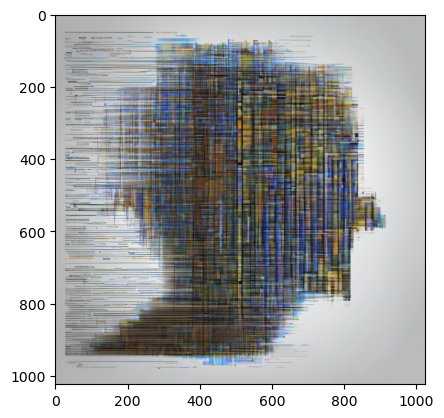

In [8]:
if(len(message) > maxLength):
    print("Input exceeds maximum character limit")
else:
    messgae_len, stegoImage = hideMessage(message, img)
    plt.imshow(stegoImage) # show the stego image

In [9]:
# save the stego image 
plt.imsave('stegoImg.png', stegoImage)

##### 3- Extract the secret message from the stego image

In [10]:
extractSecretMessage(stegoImage, len(message))

'This is a test for block distribution technique used in LSB steganography'

#### Visual comparison between original cover image and stego image:

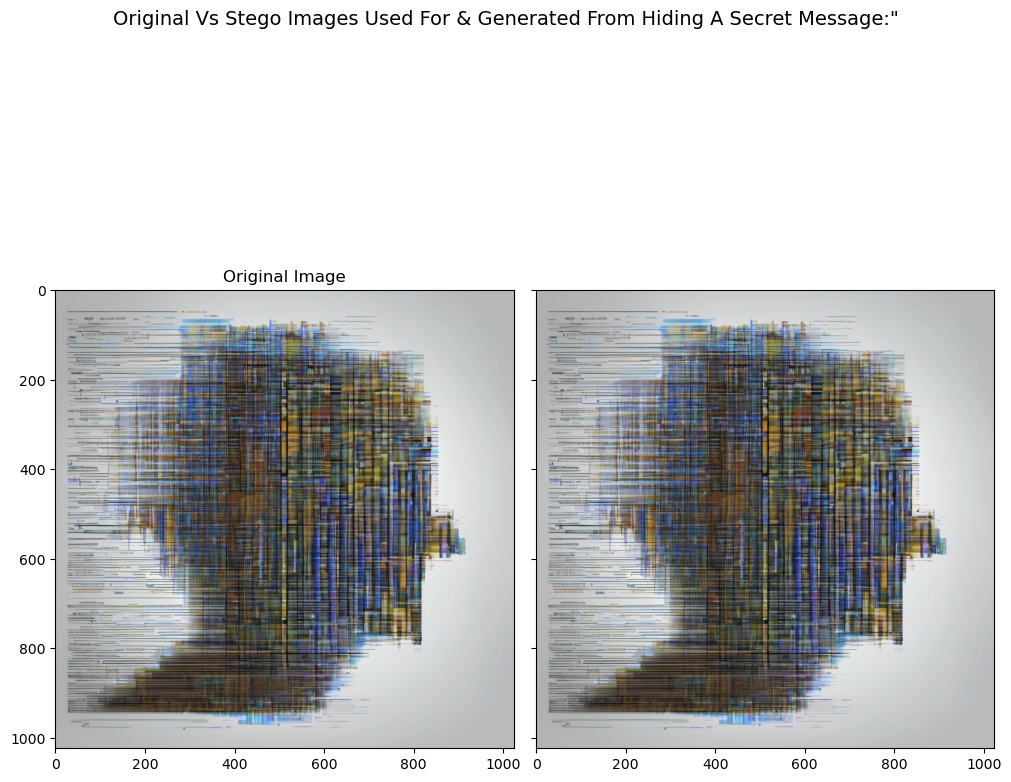

Embedded Message: This is a test for block distribution technique used in LSB steganography


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 10), sharey=True, constrained_layout=True)
fig.suptitle(f'Original Vs Stego Images Used For & Generated From Hiding A Secret Message:"', fontsize=14)
axes[0].imshow(img)
axes[0].set_title("Original Image");
axes[1].imshow(stegoImage)
plt.show()
print(f"Embedded Message: {message}")